In [1]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split

#Daten hochladen
data=pd.read_csv(r"C:\Users\hp\PycharmProjects\PythonProject\ai4i2020.csv")

#Auswahl von Features und ableiten
y=data["Machine failure"]
X=data.drop(["Machine failure","UDI", "Product ID", "TWF", "HDF", "PWF", "OSF", "RNF"],axis=1)
X['temp_diff']=data['Process temperature [K]']-data['Air temperature [K]']
X['power']=data['Rotational speed [rpm]']*data['Torque [Nm]'] / 9549
X['wear_torque']=data['Tool wear [min]']*data['Torque [Nm]']
X=pd.get_dummies(X, columns=['Type'], drop_first=True)

#Datenaufteilung
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=7)
RF=RandomForestClassifier(
    class_weight='balanced',
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=7,
    random_state=7,
    n_jobs=-1
)

#die Vohersage
RF.fit(X_train,y_train)
prediction=RF.predict(X_test)

#die Ergebnisse
print(classification_report(y_test,prediction))
print(f'Die Gesamtgenauigkeit des Modells beträgt: %{accuracy_score(y_test,prediction)*100}')


              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1922
           1       0.81      0.81      0.81        78

    accuracy                           0.98      2000
   macro avg       0.90      0.90      0.90      2000
weighted avg       0.98      0.98      0.98      2000

Die Gesamtgenauigkeit des Modells beträgt: %98.5


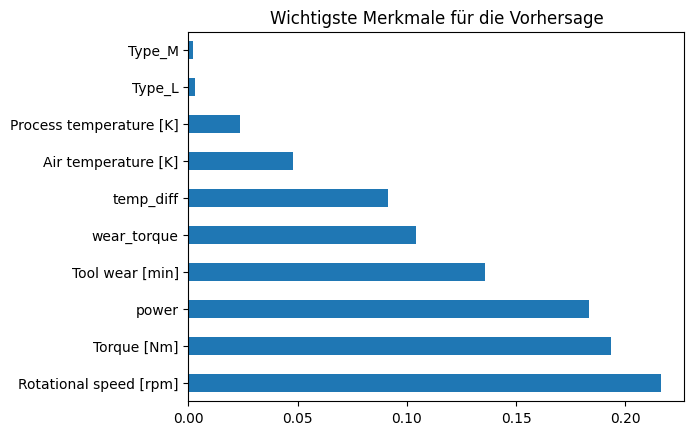

In [2]:
import matplotlib.pyplot as plt
importances = pd.Series(RF.feature_importances_, index=X.columns)
importances.nlargest(10).plot(kind='barh')
plt.title("Wichtigste Merkmale für die Vorhersage")
plt.show()

In [3]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

# StratifiedKFold sorgt dafür, dass die Ausfallrate in den Daten über alle Segmente hinweg gleich bleibt.
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=7)

# Kreuzvalidierung zur Sicherstellung der Genauigkeit
cv_accuracy = cross_val_score(RF, X, y, cv=skf, scoring='accuracy')

# Kreuzvalidierung der F1-Werte
cv_f1 = cross_val_score(RF, X, y, cv=skf, scoring='f1')

print(f"Die durchschnittliche Genauigkeit (Mean Accuracy): %{cv_accuracy.mean()*100:.2f}")
print(f"Der durchschnittliche F1-Score: %{cv_f1.mean()*100:.2f}")

Die durchschnittliche Genauigkeit (Mean Accuracy): %98.71
Der durchschnittliche F1-Score: %81.68


In [10]:
#Model speichern
import joblib
try:
    joblib.dump(RF,'ai4i2020_model.pkl')
    print("Das Modell wird erfolgreich gespeichert")
except Exception as e:
    print(f'Das Modell konnte nicht gespeichert werden: {e}')


Das Modell wird erfolgreich gespeichert


In [4]:
from sklearn.preprocessing import LabelEncoder
import numpy as np
from sklearn.impute import SimpleImputer

#Daten hochladen
data2=pd.read_csv(r"C:\Users\hp\PycharmProjects\PythonProject\aps_failure_training_set.csv", skiprows=20)
dataTest=pd.read_csv(r"C:\Users\hp\PycharmProjects\PythonProject\aps_failure_test_set.csv", skiprows=20)

#Verandern 'na' mit NaN
data2.replace('na', np.nan, inplace=True)
dataTest.replace('na', np.nan, inplace=True)

#Die Definition der Klasse (Klasse) lautet wie folgt: neg=0, pos=1
le=LabelEncoder()
y_train = le.fit_transform(data2['class'])
y_test = le.transform(dataTest['class'])
X_train = data2.drop('class', axis=1).apply(pd.to_numeric)
X_test = dataTest.drop('class', axis=1).apply(pd.to_numeric)

#Ergänzen Sie die fehlenden Werte mit dem Median.
imputer = SimpleImputer(strategy='median')
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

In [5]:
from sklearn.ensemble import HistGradientBoostingClassifier
hgbc=HistGradientBoostingClassifier(
    max_iter=100,
    max_depth=5,
    random_state=7,
    learning_rate=0.1
)
hgbc.fit(X_train, y_train)
y_pred=hgbc.predict(X_test)
print(classification_report(y_test,y_pred))
print(f'Die Gesamtgenauigkeit des Modells beträgt: %{accuracy_score(y_test,y_pred)*100}')

              precision    recall  f1-score   support

           0       0.99      1.00      1.00     15625
           1       0.92      0.71      0.80       375

    accuracy                           0.99     16000
   macro avg       0.96      0.86      0.90     16000
weighted avg       0.99      0.99      0.99     16000

Die Gesamtgenauigkeit des Modells beträgt: %99.1875


In [6]:
from sklearn.metrics import confusion_matrix
y_probs = hgbc.predict_proba(X_test)[:,1]

y_new_pred = (y_probs >= 0.10).astype(int)

print(classification_report(y_test, y_new_pred))
print(confusion_matrix(y_test, y_new_pred))

              precision    recall  f1-score   support

           0       1.00      0.99      1.00     15625
           1       0.76      0.87      0.81       375

    accuracy                           0.99     16000
   macro avg       0.88      0.93      0.90     16000
weighted avg       0.99      0.99      0.99     16000

[[15522   103]
 [   50   325]]


In [11]:
try:
    joblib.dump(RF,'sciana_predictive_maintenance_model.pkl')
    print("Das Modell wird erfolgreich gespeichert")
except Exception as e:
    print(f'Das Modell konnte nicht gespeichert werden: {e}')

Das Modell wird erfolgreich gespeichert


In [8]:
from sklearn.ensemble import IsolationForest
WindData=pd.read_csv(r"C:\Users\hp\PycharmProjects\PythonProject\T1.csv")
print(WindData.columns)
WindData['Date/Time']=pd.to_datetime(WindData['Date/Time'], dayfirst=True)
WindData['hour']= WindData['Date/Time'].dt.hour
WindData['month']= WindData['Date/Time'].dt.month
in_range=(WindData['Wind Speed (m/s)'] >= 3) & (WindData['Wind Speed (m/s)'] <= 25)
median_pwr=WindData.groupby(pd.cut(WindData['Wind Speed (m/s)'], bins=range(0, 42)))['LV ActivePower (kW)'].transform('median')
WindData['anomaly'] = 0
WindData.loc[in_range & (WindData['LV ActivePower (kW)'] < median_pwr * 0.70), 'anomaly'] = 1
df=WindData[in_range].copy()
df['efficiency']=df['LV ActivePower (kW)']/(df['Theoretical_Power_Curve (KWh)']+ 1e-6)
X = df[['Wind Speed (m/s)', 'Theoretical_Power_Curve (KWh)',
        'Wind Direction (°)', 'efficiency', 'hour', 'month']]
y = df['anomaly']
print(y.mean().round(4))
print(y.value_counts())
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=7, stratify=y)
RF3 = RandomForestClassifier(
    class_weight='balanced',
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=2,
    random_state=7,
    n_jobs=-1
)
RF3.fit(X_train, y_train)
prediction = RF3.predict(X_test)
print(classification_report(y_test, prediction))
print(accuracy_score(y_test, prediction) * 100)

Index(['Date/Time', 'LV ActivePower (kW)', 'Wind Speed (m/s)',
       'Theoretical_Power_Curve (KWh)', 'Wind Direction (°)'],
      dtype='object')
0.1319
anomaly
0    37137
1     5643
Name: count, dtype: int64


C:\Users\hp\AppData\Local\Temp\ipykernel_49660\3509570412.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  median_pwr=WindData.groupby(pd.cut(WindData['Wind Speed (m/s)'], bins=range(0, 42)))['LV ActivePower (kW)'].transform('median')


              precision    recall  f1-score   support

           0       1.00      1.00      1.00      7427
           1       0.98      0.99      0.99      1129

    accuracy                           1.00      8556
   macro avg       0.99      0.99      0.99      8556
weighted avg       1.00      1.00      1.00      8556

99.62599345488546


In [12]:
try:
    joblib.dump(RF3, 'WindData.pkl')
    print("Das Modell wird erfolgreich gespeichert")
except Exception as e:
    print(f'Das Modell konnte nicht gespeichert werden: {e}')

Das Modell wird erfolgreich gespeichert
